In [1]:
import math
import random
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from scipy import signal
from sbox import Sbox
import ciphers

In [2]:
x_0 = 0.8
def frac_part(x):
    return x - math.floor(x)

def mapping_pwlmOrbit(dyn_system,xinit,dyn_sysparams=[0.8,5,40.8],orbit_size=0):
    b2 = (dyn_sysparams[1]/dyn_sysparams[0])*dyn_sysparams[2]
    x = np.linspace(-b2,b2,500)
    y = []
    for i in range(len(x)):
        xi = dyn_system(x[i],dyn_sysparams[0],dyn_sysparams[1],dyn_sysparams[2])
        y.append(frac_part(xi))

    if orbit_size>0:
        px, py = np.empty((2,orbit_size+1))
        px[0], py[0] = xinit, 0

        # Cobweb diagram

        for n in range(1, orbit_size, 2):
            px[n] = px[n-1]
            py[n] = frac_part(dyn_system(px[n-1],dyn_sysparams[0],dyn_sysparams[1],dyn_sysparams[2]))
            px[n+1] = py[n]
            py[n+1] = py[n]
        
        return x,y,px,py
        
    return x,y


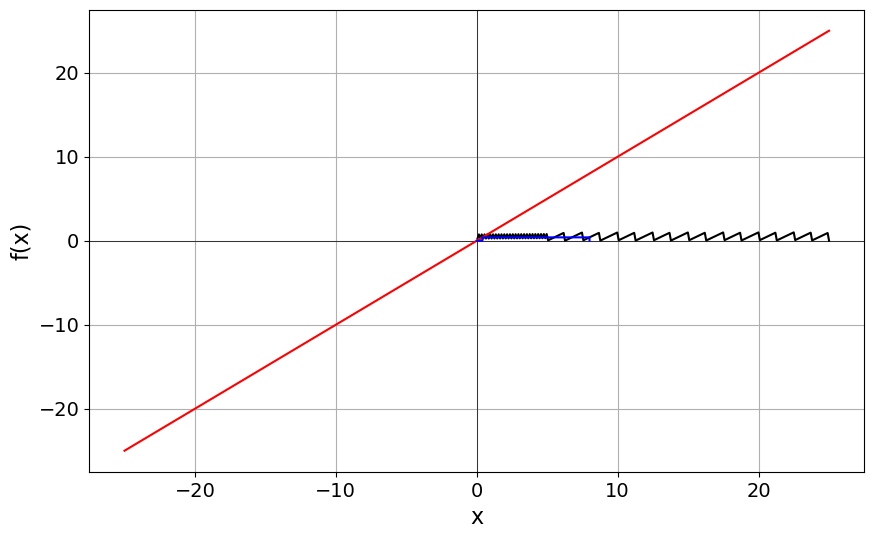

In [34]:
fig = plt.figure(figsize=(10,6))
ax = fig.add_subplot()
ax.grid(True, which='both')
ax.axhline(y=0, color='k',lw=0.5)
ax.axvline(x=0, color='k',lw=0.5)

xini = 8
xini2 = xini+0.0001
x,y,px,py = mapping_pwlmOrbit(ciphers.pwlm,xini,dyn_sysparams=[0.8,5,4],orbit_size=3000)
x2,y2,px2,py2 = mapping_pwlmOrbit(ciphers.pwlm,xini2,dyn_sysparams=[0.7,8,2.1875],orbit_size=5000)

maplenXY=int(len(x)/2)
maplenXY2=int(len(x2)/2)
ax.plot(x[maplenXY:],y[maplenXY:],'k')
# ax.plot(x[:maplenXY],y[:maplenXY],'k')
# ax.plot(x2[maplenXY:],y2[maplenXY:],'k')
# ax.plot(x2[:maplenXY],y2[:maplenXY],'k')
# ax.plot(x,y,'k')
ax.plot(x,x,'r')
# ax.plot(px[0:200],py[0:200],'b')
ax.plot(px,py,'b')
# ax.plot(px2,py2)
ax.set_ylabel('f(x)',fontsize=16)
ax.set_xlabel('x',fontsize=16)

# ax.set_xlim(-4,4)
# ax.set_ylim(np.min(y),np.max(y))
ax.tick_params(axis='both',labelsize=14)

plt.show()

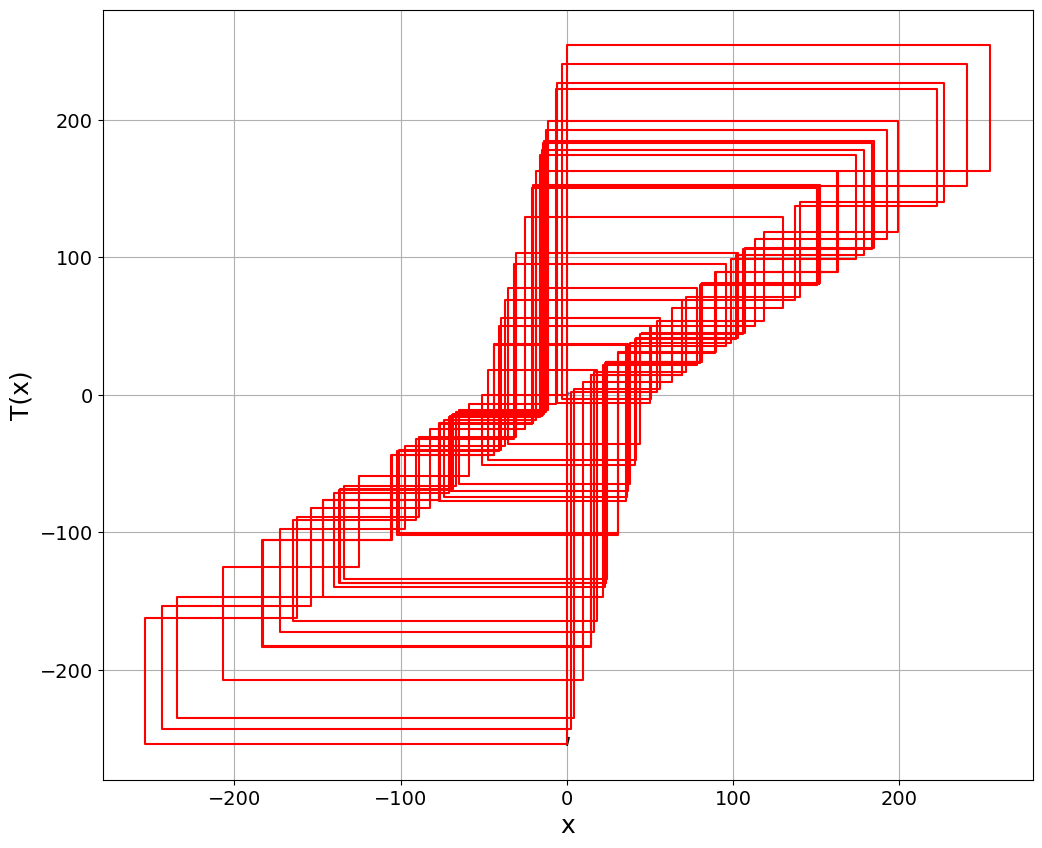

In [18]:
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot()

x = np.arange(0.1,1.1,0.02)
y = []
for i in range(len(x)):
    y.append(ciphers.pwlm(x[i]))

x0 = 0.23
nmax =250

px, py = np.empty((2,nmax+1))
px[0], py[0] = x0, 0

# Cobweb diagram

for n in range(1, nmax, 2):
    px[n] = px[n-1]
    py[n] = ciphers.pwlm(px[n-1])
    px[n+1] = py[n]
    py[n+1] = py[n]

ax.plot(x,y,'k')
ax.plot(x,x)
ax.plot(px,py,'r')

#plt.title("Diagrama de Cobweb de la función PWL",fontsize=18)
plt.xlabel('x',fontsize=18)
plt.ylabel("T(x)",fontsize=18)
plt.tick_params(labelsize=14)
# plt.xlim(0,1)
# plt.ylim(-0.02,1.02)
plt.grid()

plt.show()

# Might $g(x_n)=f_{PWL}(x_n)*1.001-\lfloor  f_{PWL}(x_n)*1.001 \rfloor$
# be chaotic? no fixed points? same characteristics as f_{pwl}

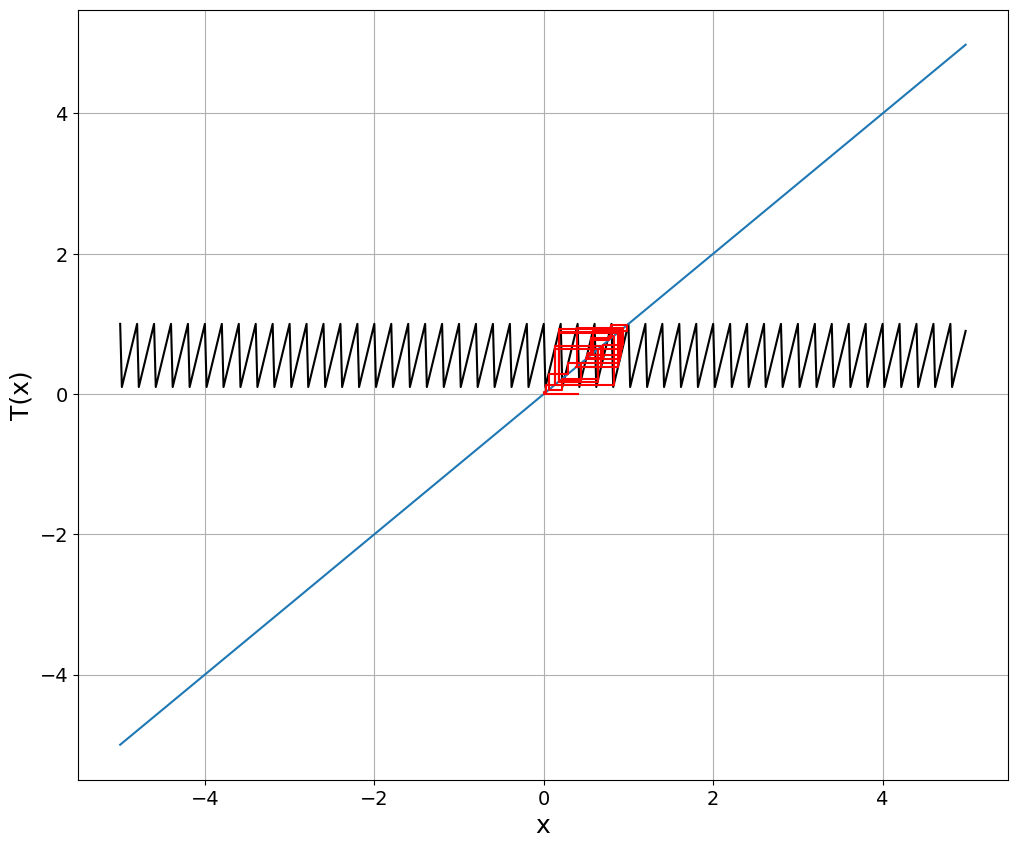

In [38]:
fig = plt.figure(figsize=(12,10))
ax = fig.add_subplot()

x = np.arange(-5,5,0.02)
y = []
for i in range(len(x)):
    y.append(frac_part(ciphers.pwlm(x[i])))

x0 = 0.4
nmax =100

px, py = np.empty((2,nmax+1))
px[0], py[0] = x0, 0

# Cobweb diagram

for n in range(1, nmax, 2):
    px[n] = px[n-1]
    py[n] = frac_part(ciphers.pwlm(px[n-1]))
    px[n+1] = py[n]
    py[n+1] = py[n]

ax.plot(x,y,'k')
ax.plot(x,x)
ax.plot(px,py,'r')

#plt.title("Diagrama de Cobweb de la función PWL",fontsize=18)
plt.xlabel('x',fontsize=18)
plt.ylabel("T(x)",fontsize=18)
plt.tick_params(labelsize=14)
# plt.xlim(0,1)
# plt.ylim(-0.02,1.02)
plt.grid()

plt.show()

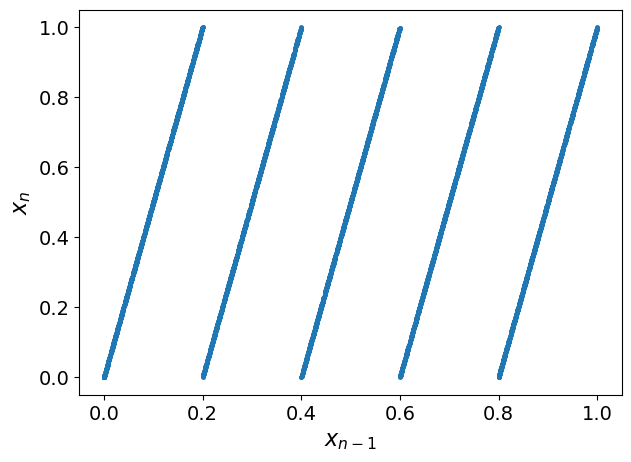

In [27]:
#PLOT X_N-1,X_N
from random import randrange
x_0 = randrange(1) 
f2 = [0.8,5,40.8]
orbit1 = []
orbit2=[]
# x1 = y_0
x2 = x_0
for i in range(6000):
    orbit2.append(x2)
    x2 = frac_part(ciphers.pwlm(x2,f2[0],f2[1],f2[2]))
    

# xn_minus1 = orbit1[:-1]
# xn = orbit1[1:]
xn_minus12 = orbit2[:-1]
xn2 = orbit2[1:]
plt.figure(figsize=(7,5))
#plt.plot(xn_minus1, xn, '.', markersize=5, label="Orbit points")
plt.plot(xn_minus12, xn2, '.', markersize=5, label="Orbit points")
plt.xlabel('$x_{n-1}$',fontsize=16)
# plt.xlim(min(orbit2),max(orbit2))
plt.ylabel("$x_n$",fontsize=16)
# plt.ylim(min(orbit2),max(orbit2))
plt.tick_params(axis='both',labelsize=14)
# plt.xlim(-256,256)
# plt.ylim(-256,256)
# plt.grid()

plt.show()

In [39]:
#
# Copyright (C) 2019 Luca Pasqualini
# University of Siena - Artificial Intelligence Laboratory - SAILab
#
# Inspired by the work of David Johnston (C) 2017: https://github.com/dj-on-github/sp800_22_tests
#
# NistRng is licensed under a BSD 3-Clause.
#
# You should have received a copy of the license along with this
# work. If not, see <https://opensource.org/licenses/BSD-3-Clause>.

# Import packages

import numpy

# Import src

from nistrng import *

if __name__ == "__main__":
    # Generate the sequence of integers and pack it in its 8-bit representation
    sequence: numpy.ndarray = numpy.random.randint(-128, 128, 1000, dtype=int)
    binary_sequence: numpy.ndarray = pack_sequence(sequence)
    # Print sequence
    print("Random sequence generated by NumPy:")
    print(sequence)
    print("Random sequence generated by NumPy encoded in 8-bit signed format:")
    print(binary_sequence)
    print("Original sequence taken back by unpacking (to check the correctness of packing process:")
    print(unpack_sequence(binary_sequence))
    # Check the eligibility of the test and generate an eligible battery from the default NIST-sp800-22r1a battery
    eligible_battery: dict = check_eligibility_all_battery(binary_sequence, SP800_22R1A_BATTERY)
    # Print the eligible tests
    print("Eligible test from NIST-SP800-22r1a:")
    for name in eligible_battery.keys():
        print("-" + name)
    # Test the sequence on the eligible tests
    results = run_all_battery(binary_sequence, eligible_battery, False)
    # Print results one by one
    print("Test results:")
    for result, elapsed_time in results:
        if result.passed:
            print("- PASSED - score: " + str(numpy.round(result.score, 3)) + " - " + result.name + " - elapsed time: " + str(elapsed_time) + " ms")
        else:
            print("- FAILED - score: " + str(numpy.round(result.score, 3)) + " - " + result.name + " - elapsed time: " + str(elapsed_time) + " ms")

Random sequence generated by NumPy:
[  26  -87    0  116 -127   53  -19   11  -95   50  -94  -24  -43  -80
   28 -116  -78 -100  -41 -128   71   53  108 -109   -1   39   29   87
    0   79  -62    4   59 -110   84  -97  -30   37   30  -18  -11   62
  -40  -51   50  -83  -65   74 -124 -117   78 -123  119 -111 -125  -71
  -19   18    1   83 -105   14  -86  -44  -68 -108   95  -24 -106   53
  -16  -71 -114   65   53   11  -65   -7   47  122  -57  -94   59   20
  -15   94  103    1  -46  -46  -60   64  -19   35   93  -86 -124   91
    9 -102   16  -28  111  -98   54   62  -13  119  -80   58   57 -119
  -12   39  -71 -104  -45  120   55  -84 -113   31  113   66  113   52
  -40   76  122   12  -24  -82  -16 -119   40    5   32   75  -28   85
  107   -9   13  -31 -102  120   77  -89  -84    9  114  115  -49  102
   -1   39  -48   80  105   33  -13   41  -83  110  126   21  -57   57
   61   95   70  -22  -14  -25  100   34 -118  108   13  -12  -74   -3
  -58  -18  -56  -16  -11   83   -3  -70 